# Fase 1: Construyendo el Multiverso del Jugador (Min. 4 Dimensiones)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Cargar dataset
url = "https://raw.githubusercontent.com/mricardo89/data-mining/main/Unit-III/datasets/players_data-2025_2026.csv"
df = pd.read_csv(url)


# Seleccionar jugador estrella, yo elegí a Harry Kane
estrella_nombre = "Harry Kane"
estrella_row = df[df['Player'] == estrella_nombre].iloc[0]

# Seleccionar al menos 4 caracteristicas continuas
columnas = ['Min', 'Gls', 'Ast', 'Sh', 'SoT']
for col in columnas:
    df[col] = df[col].astype(float)

# Pregunta de control: normalizacion Min-Max para que Minutos no aplaste a Goles
# Formula: (X - min) / (max - min)
df_norm = df.copy()
for col in columnas:
    df_norm[col + '_norm'] = (df[col] - df[col].min()) / (df[col].max() - df[col].min())

norm_cols = [col + '_norm' for col in columnas]

# Vector de la estrella y matriz de candidatos
vector_estrella = df_norm[df_norm['Player'] == estrella_nombre][norm_cols].values[0]
df_candidatos = df_norm[df_norm['Player'] != estrella_nombre].copy()
matriz_candidatos = df_candidatos[norm_cols].values

print(f"Jugador estrella seleccionado: {estrella_nombre}")
print("Vector normalizado de la estrella:", vector_estrella)

Jugador estrella seleccionado: Harry Kane
Vector normalizado de la estrella: [0.69494004 1.         0.23809524 0.81506849 1.        ]


### Respuesta:
Se usaria una tecnica de normalizacion o escalamiento como minmax o Zscore, ya que si no se hace esto, las distancias serian muy parecidas porque no se ve una diferencia en los rangos de numeros peque;os a comparacion de los numeros mayores.

# Fase 2: El Duelo de Distancias (Euclidiana vs. Manhattan)


Mide la suma de las diferencias absolutas entre las coordenadas de dos vectores, calculando la distancia en ángulos rectos como en una cuadrícula urbana.

In [10]:
# Distancia Euclidiana
diferencias = matriz_candidatos - vector_estrella
df_candidatos['dist_euclidiana'] = np.sqrt(np.sum(diferencias**2, axis=1))

# Reemplazo sugerido con distancia euclidiana
reemplazo_euc = df_candidatos.sort_values(by='dist_euclidiana').iloc[0]
print(f"Reemplazo sugerido (Euclidiana): {reemplazo_euc['Player']} ({reemplazo_euc['Squad']})")
print(f"Distancia euclidiana: {reemplazo_euc['dist_euclidiana']:.4f}")

Reemplazo sugerido (Euclidiana): Erling Haaland (Manchester City)
Distancia euclidiana: 0.3576


In [11]:
# Funcion custom para Distancia Manhattan
def calcular_manhattan(u, v):
    return np.sum(np.abs(u - v), axis=1)

# Calcular distancia manhattan
df_candidatos['dist_manhattan'] = calcular_manhattan(matriz_candidatos, vector_estrella)

# Reemplazo sugerido con distancia manhattan
reemplazo_man = df_candidatos.sort_values(by='dist_manhattan').iloc[0]
print(f"Reemplazo sugerido (Manhattan): {reemplazo_man['Player']} ({reemplazo_man['Squad']})")
print(f"Distancia manhattan: {reemplazo_man['dist_manhattan']:.4f}")

Reemplazo sugerido (Manhattan): Kylian Mbappé (Real Madrid)
Distancia manhattan: 0.6151


### Respuesta:

El algoritmo no eligio al mismo jugador, con la distancia euclidiana el reemplazo mas cercano fue erling haaland y con manhattan fue mbappe

La diferencia entre estas es que la euclidiana eleva las diferencias al cuadrado, asi penalizando fuertemente una diferencia en caracteristica grande. Haaland tiene diferencias mas parejas en todas las variables con respecto a harry kane, pero con manhattan solo suma las diferencias absolutas de manera lineal, y asi mbappe acumulo menos distancia total que haaland


# Fase 3: El Reto de Visualización en 4D

Investigamos que para visualizar más de 3 dimensiones en una pantalla 2D se pueden usar gráficos de radar (spider charts), donde cada dimensión es un eje radial y los jugadores forman polígonos que se pueden comparar directamente.

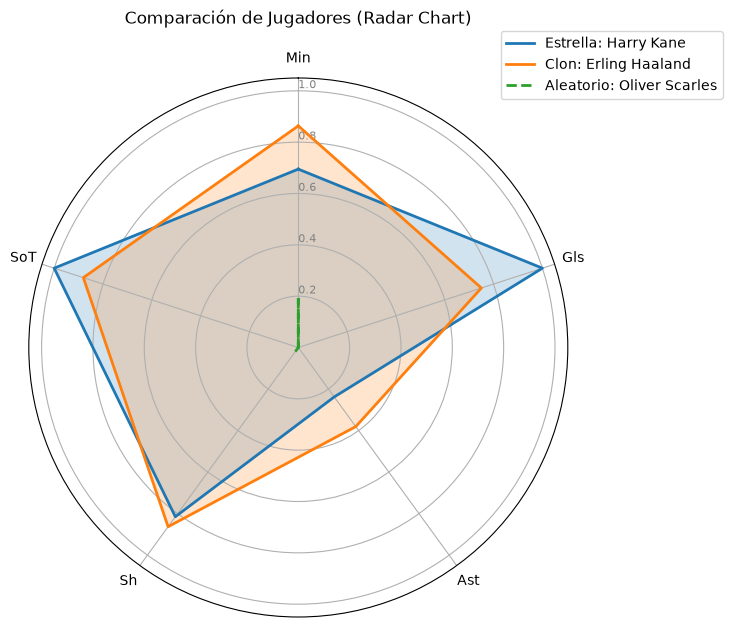

In [4]:
# Seleccionar los 3 jugadores: estrella, reemplazo y uno aleatorio
clon_nombre = reemplazo_euc['Player']

np.random.seed(42)
aleatorio_row = df_candidatos[df_candidatos['Min'] > 500].sample(1).iloc[0]
aleatorio_nombre = aleatorio_row['Player']

# Obtener valores normalizados
val_estrella = vector_estrella.tolist()
val_clon = df_candidatos[df_candidatos['Player'] == clon_nombre][norm_cols].values[0].tolist()
val_aleatorio = df_candidatos[df_candidatos['Player'] == aleatorio_nombre][norm_cols].values[0].tolist()

# Cerrar el radar
val_estrella += val_estrella[:1]
val_clon += val_clon[:1]
val_aleatorio += val_aleatorio[:1]

# Angulos para el radar
N = len(columnas)
angulos = [n / float(N) * 2 * np.pi for n in range(N)]
angulos += angulos[:1]

# Graficar
plt.figure(figsize=(7, 7))
ax = plt.subplot(111, polar=True)
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)

plt.xticks(angulos[:-1], columnas)
ax.set_rlabel_position(0)
plt.yticks([0.2, 0.4, 0.6, 0.8, 1.0], ["0.2", "0.4", "0.6", "0.8", "1.0"], color="grey", size=8)
plt.ylim(0, 1.05)

# Graficar lineas y relleno
ax.plot(angulos, val_estrella, linewidth=2, label=f"Estrella: {estrella_nombre}")
ax.fill(angulos, val_estrella, alpha=0.2)

ax.plot(angulos, val_clon, linewidth=2, label=f"Clon: {clon_nombre}")
ax.fill(angulos, val_clon, alpha=0.2)

ax.plot(angulos, val_aleatorio, linewidth=2, linestyle='dashed', label=f"Aleatorio: {aleatorio_nombre}")
ax.fill(angulos, val_aleatorio, alpha=0.1)

plt.title("Comparación de Jugadores (Radar Chart)", pad=20)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.show()

Visualmente se puede comprobar que el polígono de Harry Kane y el de Erling Haaland están prácticamente superpuestos, lo que demuestra que en el hiperespacio están muy cerca, mientras que el jugador aleatorio tiene una forma completamente diferente y alejada.